# AI Agents - UC2 DQN
#### Rolando Armas, Phd
## Lab: CartPole-v1 Basics

### Learning Objectives 

Implement a very basic scenario with gymnasium CartPole-v1 

Understand the settings and variables of the CartPole-v1 environment 

### Introduction
Minimal exploration of the `CartPole-v1` environment from [Gymnasium](https://gymnasium.farama.org/). This notebook:

1. Creates the environment and prints its observation/action spaces.
2. Runs a few episodes with **random actions** (no learning yet) to show how `reset()` and `step()` work.

This is a precursor to building a DQN agent — understanding the raw environment interface first makes the learning code much easier to follow.

### Gymnasium Cart Pole Basis

A pole is attached by an un-actuated joint to a cart, which moves along a frictionless track. The pendulum is placed upright on the cart, and the goal is to balance the pole by applying forces in the left and right direction on the cart. 



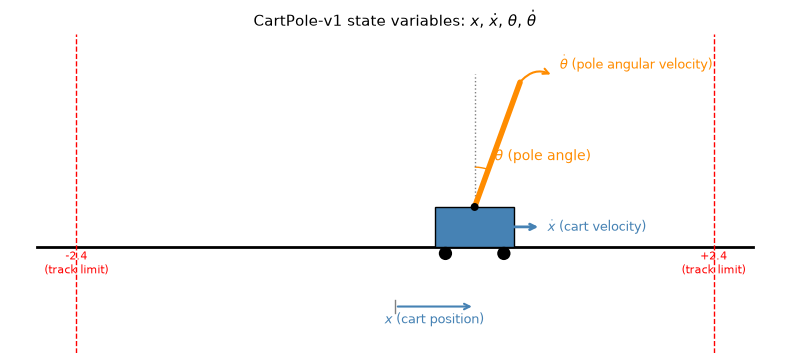

In [5]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 4))

# --- Track ---
TRACK_LIMIT = 2.4  # episode terminates if |x| > 2.4
ax.plot([-TRACK_LIMIT - 0.3, TRACK_LIMIT + 0.3], [0, 0], color="black", lw=2, zorder=1)
for limit, label in ((-TRACK_LIMIT, "-2.4"), (TRACK_LIMIT, "+2.4")):
    ax.axvline(limit, color="red", linestyle="--", lw=1)
    ax.text(limit, -0.2, f"{label}\n(track limit)", ha="center", color="red", fontsize=8)

# --- Cart (drawn off-center so x is visibly non-zero) ---
cart_x, cart_w, cart_h = 0.6, 0.6, 0.3
ax.add_patch(patches.Rectangle((cart_x - cart_w / 2, 0), cart_w, cart_h,
                                facecolor="steelblue", edgecolor="black", zorder=3))
for dx in (-cart_w / 2 + 0.08, cart_w / 2 - 0.08):
    ax.add_patch(patches.Circle((cart_x + dx, -0.05), 0.05, facecolor="black", zorder=4))

# --- Pole, tilted by theta from vertical ---
pole_len = 1.0
theta = np.deg2rad(20)
pivot = (cart_x, cart_h)
pole_tip = (pivot[0] + pole_len * np.sin(theta), pivot[1] + pole_len * np.cos(theta))
ax.plot([pivot[0], pole_tip[0]], [pivot[1], pole_tip[1]], color="darkorange", lw=4,
         solid_capstyle="round", zorder=5)
ax.add_patch(patches.Circle(pivot, 0.03, facecolor="black", zorder=6))

# Vertical reference line (theta = 0) and angle arc
ax.plot([pivot[0], pivot[0]], [pivot[1], pivot[1] + pole_len], color="gray", linestyle=":", lw=1, zorder=2)
ax.add_patch(patches.Arc(pivot, 0.6, 0.6, angle=0, theta1=90 - np.rad2deg(theta), theta2=90, color="darkorange"))
ax.text(pivot[0] + 0.15, pivot[1] + 0.35, r"$\theta$ (pole angle)", color="darkorange", fontsize=10)

# --- Cart velocity arrow (x_dot) ---
ax.annotate("", xy=(cart_x + 0.5, cart_h / 2), xytext=(cart_x + 0.05, cart_h / 2),
            arrowprops=dict(arrowstyle="->", color="steelblue", lw=2))
ax.text(cart_x + 0.55, cart_h / 2, r"$\dot{x}$ (cart velocity)", color="steelblue", va="center", fontsize=9)

# --- Pole angular velocity arrow (theta_dot) ---
ax.annotate("", xy=(pole_tip[0] + 0.25, pole_tip[1] + 0.05), xytext=(pole_tip[0], pole_tip[1]),
            arrowprops=dict(arrowstyle="->", color="darkorange", lw=1.5, connectionstyle="arc3,rad=-0.4"))
ax.text(pole_tip[0] + 0.3, pole_tip[1] + 0.1, r"$\dot{\theta}$ (pole angular velocity)",
        color="darkorange", fontsize=9)

# --- Cart position arrow (x), measured from track center ---
ax.annotate("", xy=(cart_x, -0.45), xytext=(0, -0.45), arrowprops=dict(arrowstyle="->", color="steelblue", lw=1.5))
ax.plot([0, 0], [-0.4, -0.5], color="gray", lw=1)  # origin tick
ax.text(cart_x / 2, -0.58, r"$x$ (cart position)", color="steelblue", ha="center", fontsize=9)

ax.set_xlim(-TRACK_LIMIT - 0.5, TRACK_LIMIT + 0.5)
ax.set_ylim(-0.8, 1.6)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title(r"CartPole-v1 state variables: $x$, $\dot{x}$, $\theta$, $\dot{\theta}$", fontsize=11)

plt.tight_layout()
plt.show()

The diagram above shows the four values returned in every observation (`state`) from `env.step()` / `env.reset()`:

| Symbol | Meaning | Observed range (`CartPole-v1`) | Episode ends when |
|---|---|---|---|
| $x$ | Cart position on the track | $[-4.8,\ 4.8]$ m | $\lvert x \rvert > 2.4$ m |
| $\dot{x}$ | Cart velocity | $(-\infty,\ \infty)$ m/s | — |
| $\theta$ | Pole angle from vertical | $[-0.4189,\ 0.4189]$ rad ($\pm24^\circ$) | $\lvert \theta \rvert > 0.2094$ rad ($12^\circ$) |
| $\dot{\theta}$ | Pole angular velocity | $(-\infty,\ \infty)$ rad/s | — |

Note: the observation space bounds (`low`/`high`) are wider than the actual termination thresholds for `x` and `theta` — Gymnasium gives extra headroom so values can still be observed slightly beyond the point where the episode would already have terminated.

### Reward range 
Since the goal is to keep the pole upright for as long as possible, by default, a reward of +1 is given for every step taken, including the termination step. The default reward threshold is 500 for v1 and 200 for v0 due to the time limit on the environment. 

 

### Max episode steps
env.spec.max_episode_steps (500), the step count at which Gymnasium truncates the episode if the pole hasn't fallen yet. 


## Setup

The `KMP_DUPLICATE_LIB_OK` / `OMP_NUM_THREADS` / `MKL_NUM_THREADS` environment variables must be set **before** `numpy`/`torch` are imported. On macOS, conda's `numpy`/`llvm-openmp` and PyTorch's bundled `libiomp5` can both try to initialize OpenMP, which crashes the process with a duplicate runtime error. Setting these defaults avoids that crash.

In [6]:
import os

os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')

import gymnasium as gym

## Configuration

Number of random-action episodes to roll out.

In [7]:
NUM_EPISODES = 3

## Describe the environment

`describe_env` prints the key specification details of a Gymnasium environment:

- **Observation space**: the ranges for cart position, cart velocity, pole angle, and pole angular velocity.
- **Action space**: discrete, 2 actions — `0` = push left, `1` = push right.
- **Reward threshold / max episode steps**: taken from the environment spec, when available.

In [11]:
def describe_env(env: gym.Env) -> None:
    print("=== Environment spec ===")
    print(f"Observation space: {env.observation_space}")
    print(f"  low:  {env.observation_space.low}")
    print(f"  high: {env.observation_space.high}")
    print(f"Action space: {env.action_space} (0=push left, 1=push right)")
    print(f"Reward range: {env.spec.reward_threshold if env.spec else 'n/a'}")
    print(f"Max episode steps: {env.spec.max_episode_steps if env.spec else 'n/a'}")
    print()

In [12]:
env = gym.make("CartPole-v1")
describe_env(env)

=== Environment spec ===
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
  low:  [-4.8               -inf -0.41887903        -inf]
  high: [4.8               inf 0.41887903        inf]
Action space: Discrete(2) (0=push left, 1=push right)
Reward range: 475.0
Max episode steps: 500



## What is an Episode? 

In this code, an episode is one full run of the environment from start to finish. 

For CartPole: 

The agent starts from an initial state, 
it interacts with the environment step by step, 
and the episode ends when: 
the pole falls over, or 
the cart goes out of bounds, or 
the environment reaches a terminal condition. 

So: 

each episode = one game/trajectory. 

each step = one action taken inside that episode. 

In the training loop, the code keeps taking steps until the episode ends, then resets the environment and starts a new episode. 
 

### Run a single episode

`run_episode` resets the environment (seeded with the episode index for reproducibility), then repeatedly samples a **random action** and steps the environment until it terminates (pole falls / cart goes out of bounds) or truncates (step limit reached). The first 100 steps are printed for inspection; the full total reward and step count are printed at the end.

In [9]:
def run_episode(env: gym.Env, episode_idx: int) -> None:
    state, info = env.reset(seed=episode_idx)
    print(f"--- Episode {episode_idx} ---")
    print(f"Initial state (cart pos, cart vel, pole angle, pole ang vel): {state}")
    print(f"Reset info: {info}")

    total_reward = 0.0
    step = 0
    terminated = truncated = False
    while not (terminated or truncated):
        action = env.action_space.sample()
        state, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        step += 1
        if step <= 100:
            print(f"  step {step}: action={action} state={state} reward={reward} "
                  f"terminated={terminated} truncated={truncated}")

    print(f"Episode {episode_idx} finished after {step} steps, total reward={total_reward}")
    print(f"Ended due to: {'terminated (pole fell / cart out of bounds)' if terminated else 'truncated (step limit reached)'}")
    print()

### How is reward produced? 

env.step(action) returns reward 

For CartPole-v1, that reward is: 

1.0 for every step the episode continues 

until the pole falls too far or the cart leaves the allowed position 

So, the total reward is effectively the number of time steps the pole stays balanced 

## Run it

Create the `CartPole-v1` environment, print its spec, roll out `NUM_EPISODES` random-action episodes, then close the environment to release its resources.

In [10]:
env = gym.make("CartPole-v1")
describe_env(env)

for episode in range(NUM_EPISODES):
    run_episode(env, episode)

env.close()

=== Environment spec ===
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
  low:  [-4.8               -inf -0.41887903        -inf]
  high: [4.8               inf 0.41887903        inf]
Action space: Discrete(2) (0=push left, 1=push right)
Reward range: 475.0
Max episode steps: 500

--- Episode 0 ---
Initial state (cart pos, cart vel, pole angle, pole ang vel): [ 0.01369617 -0.02302133 -0.04590265 -0.04834723]
Reset info: {}
  step 1: action=1 state=[ 0.01323574  0.17272775 -0.04686959 -0.3551522 ] reward=1.0 terminated=False truncated=False
  step 2: action=1 state=[ 0.0166903   0.3684837  -0.05397264 -0.66223824] reward=1.0 terminated=False truncated=False
  step 3: action=0 state=[ 0.02405997  0.17415258 -0.0672174  -0.3870263 ] reward=1.0 terminated=False truncated=False
  step 4: action=0 state=[ 0.02754302 -0.01995402 -0.07495793 -0.11627097] reward=1.0 terminated=False truncated=False
  step 5